<a href="https://colab.research.google.com/github/deepaksannurkards22-source/image-classification-cnn/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN Image Classification**

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#load the data

(train_images, train_labels),(test_images,test_labels) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
train_images[0] #0-1

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [5]:
train_images = train_images.astype('float32')/255
test_images = test_images.astype('float32')/255

In [6]:
train_images[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [7]:
len(train_images)

60000

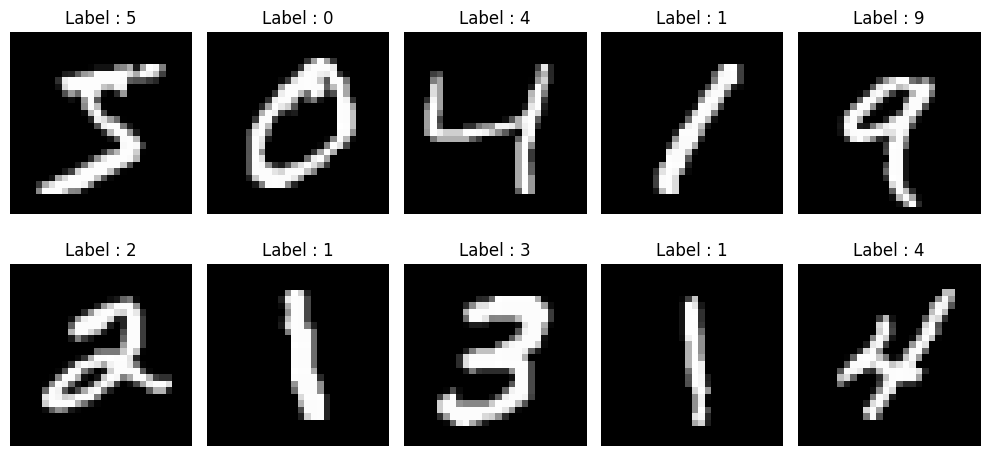

In [8]:
#see the data
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  img = train_images[i]
  plt.imshow(img, cmap='gray')
  plt.title(f"Label : {train_labels[i]}")
  plt.axis("off")
plt.tight_layout()

In [9]:
train_images = train_images.reshape((-1,28,28,1))  #mono channel image yes
test_images = test_images.reshape((-1,28,28,1))

In [10]:
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [11]:
train_labels[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10)
])

In [13]:
#building the cnn arch

In [14]:
#random numbers -

def create_model():
  model = models.Sequential([
      data_augmentation,
      #layer-1
      layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
      layers.BatchNormalization(), #this step do not skip
      layers.MaxPooling2D((2,2)), #this step do not skip
      #layer-2
      layers.Conv2D(64, (3,3), activation='relu'),
      layers.BatchNormalization(), #this step do not skip
      layers.MaxPooling2D((2,2)), #this step do not skip
      #layer-3
      layers.Conv2D(64, (3,3), activation='relu'),
      layers.BatchNormalization(), #this step do not skip

      #flatten
      layers.Flatten(),

      #Artificial Neural Network

      layers.Dense(128, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(10, activation='softmax')
  ])
  return model

In [15]:
model = create_model()

In [16]:
model.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
#call back

early_stopping = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.2, patience=3)

In [18]:
history = model.fit(train_images, train_labels, epochs=30,
                    validation_split=0.10, batch_size=10, callbacks=[early_stopping,reduce_lr])

Epoch 1/30
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 115s 20ms/step - accuracy: 0.9216 - loss: 0.2630 - val_accuracy: 0.9830 - val_loss: 0.0660 - learning_rate: 0.0010
Epoch 2/30
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 110s 20ms/step - accuracy: 0.9585 - loss: 0.1474 - val_accuracy: 0.9840 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 3/30
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 105s 19ms/step - accuracy: 0.9670 - loss: 0.1170 - val_accuracy: 0.9825 - val_loss: 0.0738 - learning_rate: 0.0010
Epoch 4/30
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 107s 20ms/step - accuracy: 0.9717 - loss: 0.1007 - val_accuracy: 0.9890 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 5/30
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 107s 20ms/step - accuracy: 0.9745 - loss: 0.0924 - val_accuracy: 0.9907 - val_loss: 0.0480 - learning_rate: 0.0010
Epoch 6/30
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 106s 20ms/step - accuracy: 0.9766 - loss: 0.0821 - val_accuracy: 0.9882 - val_loss: 0.0560 - learning_rate: 0.0010
Epoch 7/30
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 143s 20ms/step -

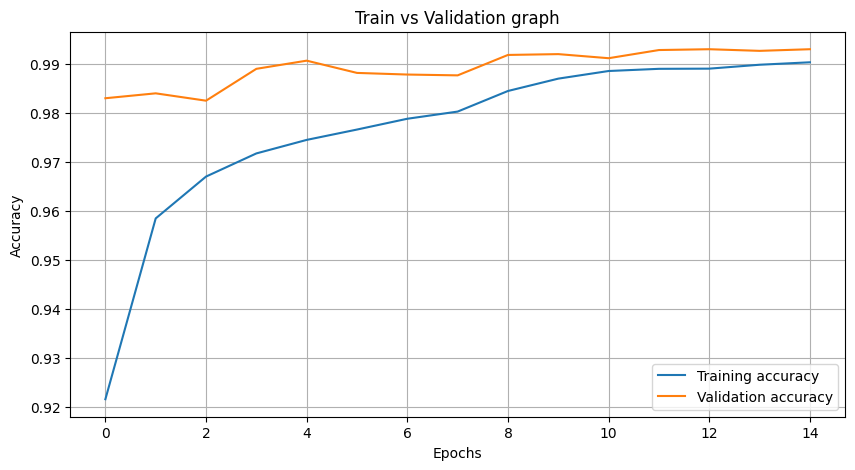

In [19]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title("Train vs Validation graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

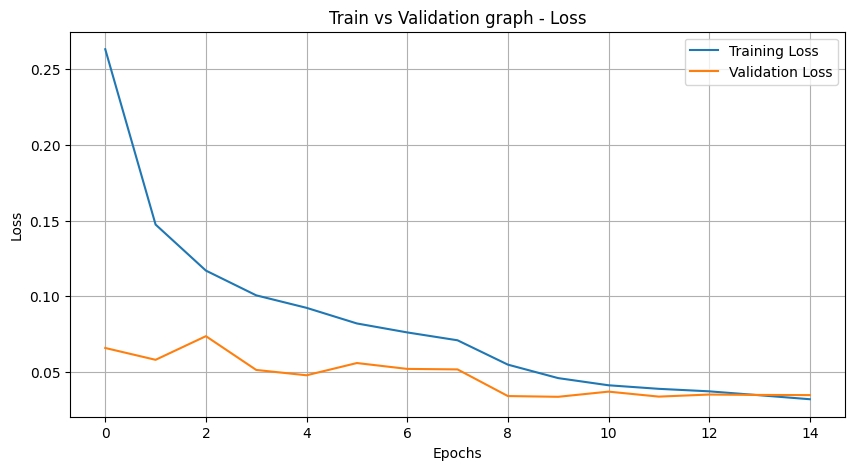

In [20]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Train vs Validation graph - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

In [21]:
#save the model

In [22]:
model.save("mnist_cnn_model.keras") #keras

In [23]:
#load the model
from PIL import Image, ImageOps

In [24]:
def predict_image(image_path, model):
  #load the image
  img = Image.open(image_path).convert("L") #gray scale
  img = ImageOps.invert(img)
  img = img.resize((28,28))
  img_array = np.array(img)
  img_array = img_array.astype('float32')/255
  img_array = img_array.reshape((1,28,28,1)) #mono

  prediction = model.predict(img_array)
  predicted_class = np.argmax(prediction)
  confidence = np.max(prediction)
  return predicted_class, confidence

In [25]:
#load and make prediction
def load_model_and_prediction(image_path):
  loaded_model = tf.keras.models.load_model('mnist_cnn_model.keras')
  predicted_class, confidence = predict_image(image_path, loaded_model)
  print(f"Predicted Digit : {predicted_class}")
  print(f"Confidence : {confidence}")
  #plot and vis the data or the image you pass
  img = Image.open(image_path).convert('L')
  plt.imshow(img, cmap='gray')
  plt.title(f"Predicted : {predicted_class} (Confidence : {confidence})")
  plt.axis('off')

In [26]:
# from google.colab import files
# files.upload()




# [p1,p2,p3,p4]

# for photo in photos:
#   load_model_and_prediction(photo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Predicted Digit : 8
Confidence : 0.7964697480201721


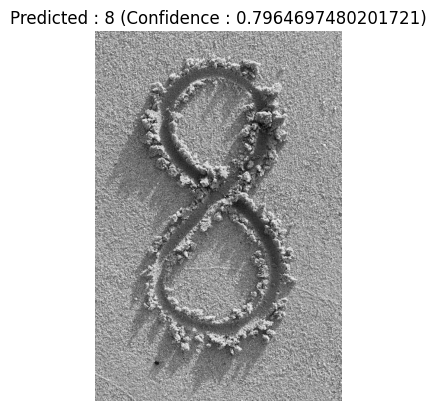

In [31]:
load_model_and_prediction("/content/image244287.jpg")